n = 0, numerical E = 0.499950, exact E = 0.500000
n = 1, numerical E = 1.499749, exact E = 1.500000
n = 2, numerical E = 2.499347, exact E = 2.500000
n = 3, numerical E = 3.498743, exact E = 3.500000
n = 4, numerical E = 4.497939, exact E = 4.500000


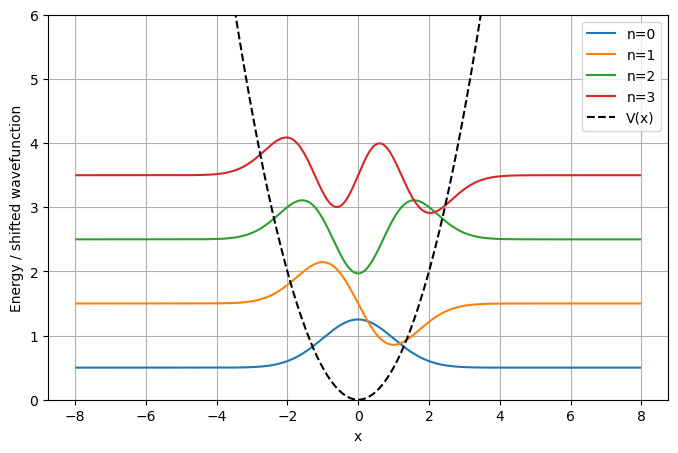

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Parameters
hbar = 1.0
m = 1.0
omega = 1.0

# Grid
N = 400
x_min = -8.0
x_max = 8.0
x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

# Interior grid for Dirichlet boundary conditions
x_int = x[1:-1]
N_int = len(x_int)

# Second derivative matrix
diag_main = -2.0 * np.ones(N_int)
diag_off = 1.0 * np.ones(N_int - 1)

D2 = (
    np.diag(diag_main)
    + np.diag(diag_off, 1)
    + np.diag(diag_off, -1)
) / dx**2

# Operators
T = -(hbar**2 / (2 * m)) * D2
V = np.diag(0.5 * m * omega**2 * x_int**2)

H = T + V

# Solve eigenvalue problem
E, psi = eigh(H)

# Normalize eigenvectors
for n in range(psi.shape[1]):
    norm = np.sqrt(np.sum(np.abs(psi[:, n])**2) * dx)
    psi[:, n] = psi[:, n] / norm

# Print first few energies
for n in range(5):
    E_exact = hbar * omega * (n + 0.5)
    print(f"n = {n}, numerical E = {E[n]:.6f}, exact E = {E_exact:.6f}")

# Plot first few wavefunctions
plt.figure(figsize=(8, 5))

for n in range(4):
    plt.plot(x_int, psi[:, n] + E[n], label=f"n={n}")

plt.plot(x_int, 0.5 * m * omega**2 * x_int**2, "k--", label="V(x)")
plt.ylim(0, 6)
plt.xlabel("x")
plt.ylabel("Energy / shifted wavefunction")
plt.legend()
plt.grid(True)
plt.show()